In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = "/Users/praneethgokeda/Documents/Applied_ML/binf610s26_hw1.data"
df = pd.read_csv(path, sep="\t", header =None)

df.columns = ["gene1", "gene2", "gene3", "gene4"]

print(df.shape)
df.head()

(3000, 4)


,gene1,gene2,gene3,gene4
0,58.871841,0.766223,8.896615,8.889810
1,59.062650,1.249438,2.335450,8.420492
2,61.050247,2.389886,5.398492,11.572695
3,78.126836,0.552165,2.974097,10.906602
4,75.849827,0.582448,6.512871,11.183212


In [18]:
X = df[["gene1", "gene2", "gene3"]]. to_numpy(dtype = float)
y = df[["gene4"]].to_numpy(dtype = float)

X_train, y_train = X[:2500], y[:2500]
X_val, y_val = X[2500:], y[2500:]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val: ", X_val.shape, "y_val:", y_val.shape)

X_train: (2500, 3) y_train: (2500, 1)
X_val:  (500, 3) y_val: (500, 1)


In [19]:
mu = X_train.mean(axis = 0, keepdims = True)
sigma = X_train.std(axis = 0, keepdims = True) + 1e-12

def standardize(X):
    return(X - mu )/ sigma

X_train_s = standardize(X_train)
X_val_s = standardize(X_val)


Closed Form Final Results (2500 train / 500 val):
Train MSE = 0.02174734740138951
Validation MSE = 0.02254147668632399
Closed form normal equation parameters:
d = 10.014108537600002
a = 1.7718800695735197
b = 1.1234737745881707
c = 0.8058049067500171


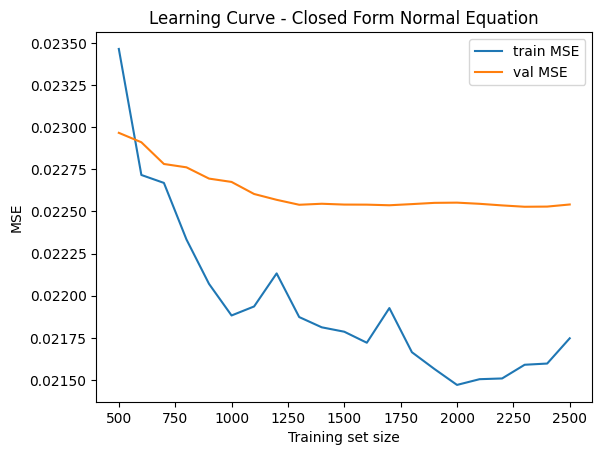

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Bias column
X_train_b = np.c_[np.ones((X_train_s.shape[0], 1)), X_train_s]
X_val_b   = np.c_[np.ones((X_val_s.shape[0], 1)),   X_val_s]

theta = np.linalg.pinv(X_train_b) @ y_train

y_train_pred_full = X_train_b @ theta
y_val_pred_full   = X_val_b @ theta

train_mse_full = np.mean((y_train - y_train_pred_full)**2)
val_mse_full   = np.mean((y_val - y_val_pred_full)**2)

print("\nClosed Form Final Results (2500 train / 500 val):")
print("Train MSE =", train_mse_full)
print("Validation MSE =", val_mse_full)

print("Closed form normal equation parameters:")
print("d =", theta[0,0])
print("a =", theta[1,0])
print("b =", theta[2,0])
print("c =", theta[3,0])

# Learning curve 
train_sizes = list(range(500, 2501, 100))
train_mse_list = []
val_mse_list = []

for m in train_sizes:
    X_m = X_train_s[:m]
    y_m = y_train[:m]

    X_m_b   = np.c_[np.ones((m, 1)), X_m]                 
    X_val_b = np.c_[np.ones((X_val_s.shape[0], 1)), X_val_s]

    theta_m = np.linalg.pinv(X_m_b) @ y_m

    y_m_pred   = X_m_b @ theta_m
    y_val_pred = X_val_b @ theta_m

    train_mse = np.mean((y_m - y_m_pred)**2)
    val_mse   = np.mean((y_val - y_val_pred)**2)

    train_mse_list.append(train_mse)
    val_mse_list.append(val_mse)


plt.figure()
plt.plot(train_sizes, train_mse_list, label="train MSE")
plt.plot(train_sizes, val_mse_list, label="val MSE")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title("Learning Curve - Closed Form Normal Equation")
plt.legend()
plt.show()





Gradient Descent parameters:
d: 10.014108537599993
a: 1.7718800695735153
b: 1.123473774588167
c: 0.805804906750014
Train MSE: 0.021747347401389505
Val MSE: 0.022541476686323995
Lengths: 21 21 21


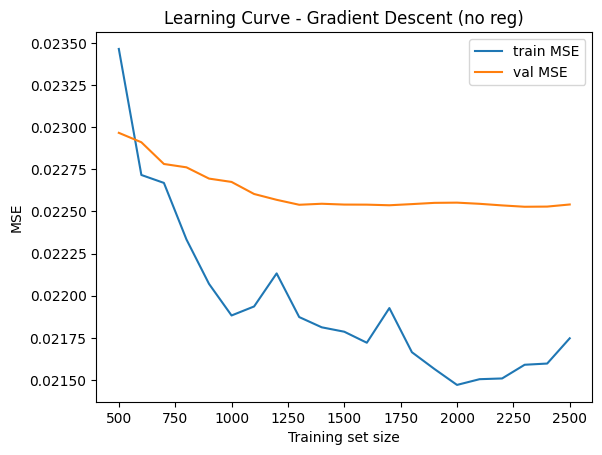

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### Gradient descent 

# Adding Bias
X_train_b = np.c_[np.ones((X_train_s.shape[0], 1)), X_train_s]
X_val_b   = np.c_[np.ones((X_val_s.shape[0], 1)),   X_val_s]   # ✅ fixed

m = X_train_b.shape[0]
learning_rate = 0.05
n_epochs = 5000
theta = np.zeros((4,1))

for epoch in range(n_epochs):
    gradient = (2/m) * X_train_b.T @ (X_train_b @ theta - y_train)
    theta = theta - learning_rate * gradient


print("Gradient Descent parameters:")
print("d:", theta[0,0])
print("a:", theta[1,0])
print("b:", theta[2,0])
print("c:", theta[3,0])

y_train_pred = X_train_b @ theta
y_val_pred   = X_val_b @ theta

train_mse = np.mean((y_train - y_train_pred) ** 2)
val_mse   = np.mean((y_val - y_val_pred) ** 2)

print("Train MSE:", train_mse)
print("Val MSE:", val_mse)


## Learning curve

train_sizes = list(range(500, 2501, 100))

train_mse_list = []
val_mse_list = []

for m in train_sizes:

    X_m = X_train_s[:m]
    y_m = y_train[:m]

    X_m_b   = np.c_[np.ones((m, 1)), X_m]
    X_val_b = np.c_[np.ones((X_val_s.shape[0], 1)), X_val_s]

    theta = np.zeros((4,1))

    for epoch in range(3000):
        gradients = (2/m) * X_m_b.T @ (X_m_b @ theta - y_m)
        theta = theta - 0.05 * gradients

    y_m_pred   = X_m_b @ theta
    y_val_pred = X_val_b @ theta

    train_mse_list.append(np.mean((y_m - y_m_pred) ** 2))
    val_mse_list.append(np.mean((y_val - y_val_pred) ** 2))



#plot once (outside loop)
plt.figure()
plt.plot(train_sizes, train_mse_list, label="train MSE")
plt.plot(train_sizes, val_mse_list, label="val MSE")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title("Learning Curve - Gradient Descent (no reg)")
plt.legend()
plt.show()

Ridge GD parameters
d: 10.014108537599993
a: 1.7649561309039448
b: 1.1181974130256336
c: 0.8018324677915755
Train MSE: 0.02176865309377701
Val MSE: 0.022602259746716216


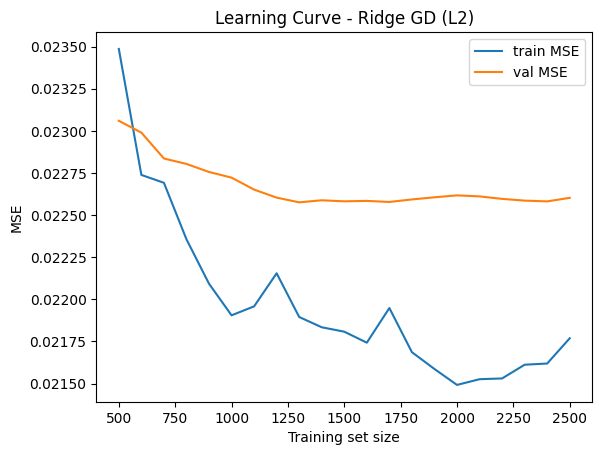

In [44]:
import numpy as np
import matplotlib.pyplot as plt

## iii) Gradient descent (ridge regularization)

# Adding bias
X_train_b = np.c_[np.ones((X_train_s.shape[0], 1)), X_train_s]
X_val_b   = np.c_[np.ones((X_val_s.shape[0], 1)),   X_val_s]

m = X_train_b.shape[0]
learning_rate = 0.05
n_epochs = 5000
alpha = 0.001

theta = np.zeros((4,1))

for epoch in range(n_epochs):
    # MSE gradient
    gradient = (2/m) * X_train_b.T @ (X_train_b @ theta - y_train)

    # Ridge penalty (do NOT penalize intercept)
    theta_reg = theta.copy()
    theta_reg[0,0] = 0
    gradient = gradient + 2 * alpha * theta_reg

    # update theta
    theta = theta - learning_rate * gradient

print("Ridge GD parameters")
print("d:", theta[0,0])
print("a:", theta[1,0])
print("b:", theta[2,0])
print("c:", theta[3,0])

y_train_pred = X_train_b @ theta
y_val_pred   = X_val_b @ theta

train_mse = np.mean((y_train - y_train_pred) ** 2)
val_mse   = np.mean((y_val - y_val_pred) ** 2)

print("Train MSE:", train_mse)
print("Val MSE:", val_mse)


## Learning curve (Ridge GD)

train_sizes = list(range(500, 2501, 100))
train_mse_list = []
val_mse_list = []

for m in train_sizes:
    X_m = X_train_s[:m]
    y_m = y_train[:m]

    X_m_b   = np.c_[np.ones((m,1)), X_m]
    X_val_b = np.c_[np.ones((X_val_s.shape[0], 1)), X_val_s]

    theta = np.zeros((4,1))

    for epoch in range(3000):
        gradients = (2/m) * X_m_b.T @ (X_m_b @ theta - y_m)

        theta_reg = theta.copy()
        theta_reg[0,0] = 0
        gradients = gradients + 2 * alpha * theta_reg

        theta = theta - 0.05 * gradients

    y_m_pred   = X_m_b @ theta
    y_val_pred = X_val_b @ theta

    train_mse_list.append(np.mean((y_m - y_m_pred) ** 2))
    val_mse_list.append(np.mean((y_val - y_val_pred) ** 2))

plt.figure()
plt.plot(train_sizes, train_mse_list, label="train MSE")
plt.plot(train_sizes, val_mse_list, label="val MSE")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title("Learning Curve - Ridge GD (L2)")
plt.legend()
plt.show()

LASSO GD parameters
d: 10.014108537599993
a: 1.7693353056865992
b: 1.1214512584206149
c: 0.804141965077587
Train MSE: 0.021750462512252967
Val MSE: 0.02255782762812304


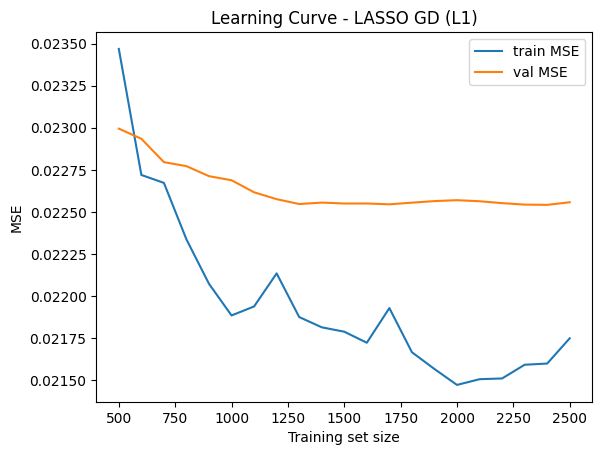

In [53]:
import numpy as np
import matplotlib.pyplot as plt

## iv) Gradient Descent (LASSO regularization)

# Adding bias
X_train_b = np.c_[np.ones((X_train_s.shape[0], 1)), X_train_s]
X_val_b   = np.c_[np.ones((X_val_s.shape[0], 1)),   X_val_s]

m = X_train_b.shape[0]
learning_rate = 0.05
n_epochs = 5000
alpha = 0.001

theta = np.zeros((4,1))

for epoch in range(n_epochs):
    # MSE gradient
    gradient = (2/m) * X_train_b.T @ (X_train_b @ theta - y_train)

    
    theta_reg = theta.copy()
    theta_reg[0,0] = 0
    gradient = gradient + alpha * np.sign(theta_reg)

    theta = theta - learning_rate * gradient

print("LASSO GD parameters")
print("d:", theta[0,0])
print("a:", theta[1,0])
print("b:", theta[2,0])
print("c:", theta[3,0])

y_train_pred = X_train_b @ theta
y_val_pred   = X_val_b @ theta

train_mse = np.mean((y_train - y_train_pred)**2)
val_mse   = np.mean((y_val - y_val_pred)**2)

print("Train MSE:", train_mse)
print("Val MSE:", val_mse)

train_sizes = list(range(500, 2501, 100))
train_mse_list = []
val_mse_list = []

alpha = 0.001

for m in train_sizes:
    X_m = X_train_s[:m]
    y_m = y_train[:m]

    X_m_b   = np.c_[np.ones((m,1)), X_m]
    X_val_b = np.c_[np.ones((X_val_s.shape[0], 1)), X_val_s]

    theta = np.zeros((4,1))

    for epoch in range(3000):
        gradients = (2/m) * X_m_b.T @ (X_m_b @ theta - y_m)

        theta_reg = theta.copy()
        theta_reg[0,0] = 0
        gradients = gradients + alpha * np.sign(theta_reg)

        theta = theta - 0.05 * gradients

    y_m_pred   = X_m_b @ theta
    y_val_pred = X_val_b @ theta

    train_mse_list.append(np.mean((y_m - y_m_pred)**2))
    val_mse_list.append(np.mean((y_val - y_val_pred)**2))

plt.figure()
plt.plot(train_sizes, train_mse_list, label="train MSE")
plt.plot(train_sizes, val_mse_list, label="val MSE")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title("Learning Curve - LASSO GD (L1)")
plt.legend()
plt.show()


In [ ]:
# Polynomial Model (degree 3 for each variable)
#Creating features
X_poly = np.column_stack([
    X[:,0], X[:,0]**2, X[:,0]**3,
    X[:,1], X[:,1]**2, X[:,1]**3,
    X[:,2], X[:,2]**2, X[:,2]**3
])

y_vec = y.ravel()

In [56]:
#random train or validation split
np.random.seed(42)
idx = np.random.permutation(len(X_poly))

train_idx = idx[:2500]
val_idx = idx[2500:]

X_train_p = X_poly[train_idx]
X_val_p   = X_poly[val_idx]

y_train_p = y_vec[train_idx]
y_val_p   = y_vec[val_idx]


#Scaling
mean = X_train_p.mean(axis=0)
std  = X_train_p.std(axis=0)

X_train_p = (X_train_p - mean) / std
X_val_p   = (X_val_p   - mean) / std


#Adding intercept column
X_train_poly = np.c_[X_train_p, np.ones(len(X_train_p))]
X_val_poly   = np.c_[X_val_p,   np.ones(len(X_val_p))]

Polynomial Ridge Train MSE: 0.0010643596088937422
Polynomial Ridge Val MSE: 0.0009300498121778985


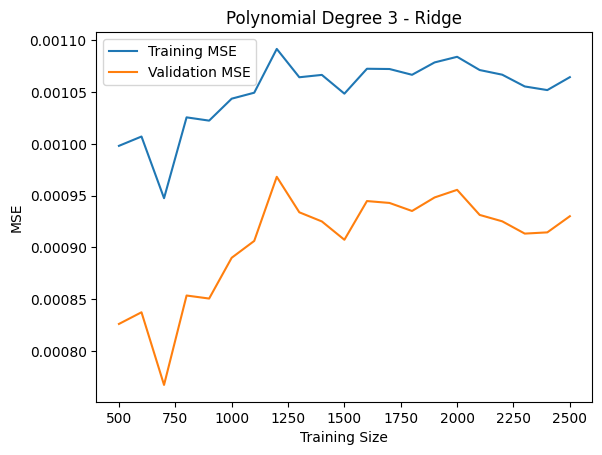

In [ ]:
#Ridge gradient descent 

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def gd_ridge(X, y, lr=0.01, epochs=5000, lam=0.1):
    n = len(y)
    theta = np.zeros(X.shape[1])

    for _ in range(epochs):
        y_pred = X @ theta
        error  = y_pred - y

        grad = (2/n) * (X.T @ error)

        # Ridge penalty
        grad[:-1] += (2 * lam / n) * theta[:-1]

        theta -= lr * grad

    return theta

#training ridge model
theta_poly_ridge = gd_ridge(X_train_poly, y_train_p, lam=0.1)

print("Polynomial Ridge Train MSE:",
      mse(y_train_p, X_train_poly @ theta_poly_ridge))

print("Polynomial Ridge Val MSE:",
      mse(y_val_p, X_val_poly @ theta_poly_ridge))

#Learning curve
train_sizes = range(500, 2501, 100)
train_errors = []

val_errors = []

for m in train_sizes:
    theta_m = gd_ridge(X_train_poly[:m], y_train_p[:m], lam=0.1)
    theta_m = gd_ridge(X_train_poly[:m], y_train_p[:m], lam  = 0.1)

    train_errors.append(mse(y_train_p[:m],
                            X_train_poly[:m] @ theta_m))

    val_errors.append(mse(y_val_p,
                          X_val_poly @ theta_m))

plt.plot(train_sizes, train_errors, label="Training MSE")
plt.plot(train_sizes, val_errors, label="Validation MSE")
plt.legend()
plt.title("Polynomial Degree 3 - Ridge")
plt.xlabel("Training Size")
plt.ylabel("MSE")
plt.show()

Polynomial LASSO Train MSE: 0.001054578829252344
Polynomial LASSO Val MSE:   0.0009213631511022487


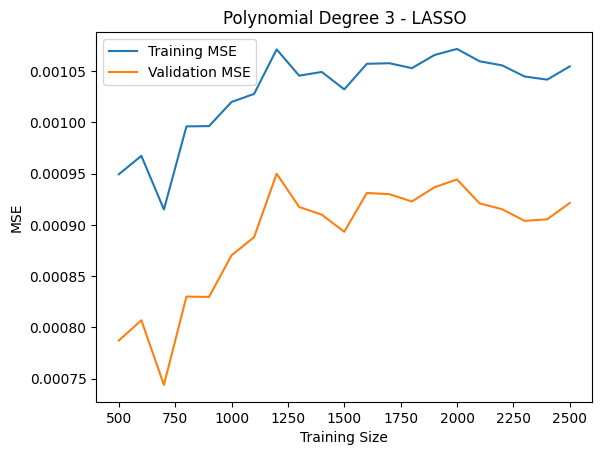

In [59]:
# ii) LASSO Gradient Descent (assumes polynomial + split + scaling already done)

def gd_lasso(X, y, lr=0.01, epochs=5000, lam=0.01):
    n = len(y)
    theta = np.zeros(X.shape[1])

    for _ in range(epochs):
        y_pred = X @ theta
        error  = y_pred - y

        grad = (2/n) * (X.T @ error)

        # LASSO penalty (do NOT penalize intercept = last column)
        grad[:-1] += (lam / n) * np.sign(theta[:-1])

        theta -= lr * grad

    return theta

# Training LASSO model
lam = 0.01
theta_poly_lasso = gd_lasso(X_train_poly, y_train_p, lr=0.01, epochs=5000, lam=lam)

print("Polynomial LASSO Train MSE:", mse(y_train_p, X_train_poly @ theta_poly_lasso))
print("Polynomial LASSO Val MSE:  ", mse(y_val_p,   X_val_poly   @ theta_poly_lasso))

# Learning curve
train_sizes = range(500, 2501, 100)
train_errors, val_errors = [], []

for m in train_sizes:
    theta_m = gd_lasso(X_train_poly[:m], y_train_p[:m], lr=0.01, epochs=5000, lam=lam)
    train_errors.append(mse(y_train_p[:m], X_train_poly[:m] @ theta_m))
    val_errors.append(mse(y_val_p,        X_val_poly       @ theta_m))

plt.figure()
plt.plot(train_sizes, train_errors, label="Training MSE")
plt.plot(train_sizes, val_errors,   label="Validation MSE")
plt.legend()
plt.title("Polynomial Degree 3 - LASSO")
plt.xlabel("Training Size")
plt.ylabel("MSE")
plt.show()

ratio = 0.0 val MSE = 0.0009218668867274302
ratio = 0.1 val MSE = 0.0009218164947849365
ratio = 0.2 val MSE = 0.0009217661034841415
ratio = 0.3 val MSE = 0.0009217157128251909
ratio = 0.4 val MSE = 0.0009216653228082228
ratio = 0.5 val MSE = 0.0009216149334333403
ratio = 0.6 val MSE = 0.0009215645281444076
ratio = 0.7 val MSE = 0.0009215141372946247
ratio = 0.8 val MSE = 0.0009214637470872695
ratio = 0.9 val MSE = 0.0009214133575224619
ratio = 1.0 val MSE = 0.0009213631511022487

Best ratio = 1.0
Elastic Net Train MSE: 0.001054578829252344
Elastic Net Val MSE:   0.0009213631511022487


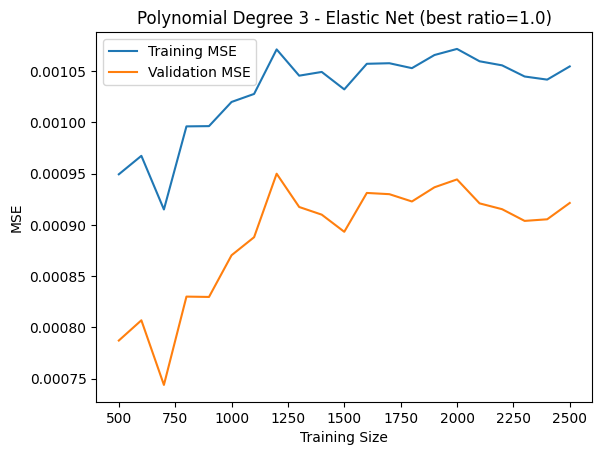

In [ ]:
# iii) Elastic Net Gradient Descent


def gd_elasticnet(X, y, lr=0.01, epochs=5000, lam=0.01, ratio=0.5):
    n = len(y)
    theta = np.zeros(X.shape[1])

    for _ in range(epochs):
        y_pred = X @ theta
        error  = y_pred - y

        grad = (2/n) * (X.T @ error)

        # Ridge part (L2) - no intercept penalty (last column)
        grad[:-1] += (2 * lam * (1 - ratio) / n) * theta[:-1]

        # LASSO part (L1) - no intercept penalty (last column)
        grad[:-1] += (lam * ratio / n) * np.sign(theta[:-1])

        theta -= lr * grad

    return theta

# Grid search ratio
lam = 0.01
ratios = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

best_ratio = None
best_theta = None
best_val_mse = float("inf")

for r in ratios:
    theta_r = gd_elasticnet(X_train_poly, y_train_p, lr=0.01, epochs=5000, lam=lam, ratio=r)
    val_mse_r = mse(y_val_p, X_val_poly @ theta_r)
    print("ratio =", r, "val MSE =", val_mse_r)

    if val_mse_r < best_val_mse:
        best_val_mse = val_mse_r
        best_ratio = r
        best_theta = theta_r

print("\nBest ratio =", best_ratio)
print("Elastic Net Train MSE:", mse(y_train_p, X_train_poly @ best_theta))
print("Elastic Net Val MSE:  ", mse(y_val_p,   X_val_poly   @ best_theta))

# Learning curve (using best_ratio)
train_sizes = range(500, 2501, 100)
train_errors, val_errors = [], []

for m in train_sizes:
    theta_m = gd_elasticnet(X_train_poly[:m], y_train_p[:m], lr=0.01, epochs=5000, lam=lam, ratio=best_ratio)
    train_errors.append(mse(y_train_p[:m], X_train_poly[:m] @ theta_m))
    val_errors.append(mse(y_val_p, X_val_poly @ theta_m))


plt.figure()
plt.plot(train_sizes, train_errors, label="Training MSE")
plt.plot(train_sizes, val_errors,   label="Validation MSE")
plt.legend()
plt.title(f"Polynomial Degree 3 - Elastic Net (best ratio={best_ratio})")
plt.xlabel("Training Size")
plt.ylabel("MSE")
plt.show()